In [2]:
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
from scipy.stats import pearsonr
sys.path.insert(0,'..')
from scripts.models.pod.model import RampPOD
from scripts.data.classes import fit_empirical_qm
warnings.filterwarnings('ignore')
pplt.rc.update({
    'tick.minor':False,
    'savefig.dpi':300,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'legend.fontsize':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
PREDSDIR   = CONFIGS['filepaths']['predictions']
MODELSDIR  = CONFIGS['filepaths']['models']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELS     = CONFIGS['experiments']
NNCONFIG   = MODELS['nn']
SRCONFIG   = MODELS['sr']
LATRANGE   = CONFIGS['domain']['latrange']
LONRANGE   = CONFIGS['domain']['lonrange']
YEARS      = CONFIGS['domain']['years']
MONTHS     = CONFIGS['domain']['months']

In [4]:
url = 'https://psl.noaa.gov/data/correlation/nina34.anom.data'
raw = pd.read_csv(url,sep=r'\s+',header=None,skiprows=1,engine='python')
raw = raw[pd.to_numeric(raw[0],errors='coerce').notna()]
raw = raw.iloc[:,:13].apply(pd.to_numeric,errors='coerce')

nino = {}
for _,row in raw.iterrows():
    year = int(row[0])
    if YEARS[0]<=year<=YEARS[-1]:
        jja = np.nanmean(row[MONTHS].to_numpy())
        if np.isfinite(jja):
            nino[year] = float(jja)

In [5]:
SRFUNCTIONS = {
    'cube':   lambda x: x**3,
    'square': lambda x: x**2,
    'neg':    lambda x: -x,
    'sqrt':   np.sqrt,'exp':np.exp,'log':np.log,
    'abs':    np.abs,'sin':np.sin,'cos':np.cos,
}

def load_all_splits(var):
    pieces = []
    for split in ['train','valid','test']:
        path = os.path.join(SPLITSDIR,f'{split}.h5')
        with xr.open_dataset(path,engine='h5netcdf') as ds:
            if var in ds:
                pieces.append(ds[var].load())
    if not pieces:
        raise KeyError(f'{var!r} not found in any split file')
    return xr.concat(pieces,dim='time')

def flatten(a,b):
    a,b  = a.values.ravel(),b.values.ravel()
    mask = np.isfinite(a)&np.isfinite(b)
    return a[mask],b[mask]

def annual_cutoff(da,years):
    slices = []
    for year in years:
        mask = da.time.dt.year==year
        if not mask.any():
            continue
        yr      = da.sel(time=mask)
        daily   = yr.resample(time='1D').sum(skipna=False)
        var     = daily.var(dim='time',skipna=True)
        mean    = daily.mean(dim='time',skipna=True)
        cutoff  = (var/mean).where(mean>0)
        slices.append(cutoff.expand_dims(year=[year]))
    return xr.concat(slices,dim='year')

def detrend_year(da):
    coeffs = da.polyfit(dim='year',deg=1,skipna=True)
    fit    = xr.polyval(da.year,coeffs.polyfit_coefficients)
    return da-fit

def pearson_map(da,ninodict):
    years     = da.year.values
    nino      = np.array([ninodict.get(int(year),np.nan) for year in years],dtype=float)
    values    = da.values.astype(float)
    nlat,nlon = values.shape[1],values.shape[2]
    rmap      = np.full((nlat,nlon),np.nan)
    pmap      = np.full((nlat,nlon),np.nan)
    for i in range(nlat):
        for j in range(nlon):
            v  = values[:,i,j]
            ok = np.isfinite(v)&np.isfinite(nino)
            if ok.sum()>=5:
                rmap[i,j],pmap[i,j] = pearsonr(nino[ok],v[ok])
    coords = {'lat':da.lat,'lon':da.lon}
    return (xr.DataArray(rmap,dims=['lat','lon'],coords=coords),
            xr.DataArray(pmap,dims=['lat','lon'],coords=coords))

def _load_kernel_weights(weightsfrom):
    wlist = []
    for seed in NNCONFIG['seeds']:
        wpath = os.path.join(WEIGHTSDIR,f'{weightsfrom}_{seed}_weights.nc')
        with xr.open_dataset(wpath,engine='h5netcdf') as wds:
            wlist.append(wds['k'].load())
    return xr.concat(wlist,dim='seed').mean('seed')

def _kernel_integrate_fields(fieldvars,splitvars,weightsmean):
    dsig_da = splitvars['dsig']
    if 'time' in dsig_da.dims:
        dsig_da = dsig_da.mean(dim='time')
    dsig   = np.asarray(dsig_da.transpose('sig').values).reshape(-1)
    result = {}
    for var in fieldvars:
        da        = splitvars[var]
        spacedims = [d for d in da.dims if d != 'sig']
        arr       = da.transpose(*spacedims,'sig').values
        w         = np.asarray(weightsmean.sel(field=var).values).reshape(-1)
        integ     = (arr.reshape(-1,arr.shape[-1])*w[None,:]*dsig[None,:]).sum(axis=1)
        coords    = {d:da.coords[d] for d in spacedims if d in da.coords}
        result[var] = xr.DataArray(integ.reshape(arr.shape[:-1]),dims=spacedims,coords=coords)
    return result

def _load_pred_split(name,split):
    fpath = os.path.join(PREDSDIR,f'{name}_{split}_predictions.nc')
    if not os.path.exists(fpath):
        return None
    with xr.open_dataset(fpath) as ds:
        pred = ds['tp'].load()
    if 'seed' in pred.dims:
        pred = pred.mean('seed')
    if 'complexity' in pred.dims:
        pred = pred.isel(complexity=0)
    return pred.squeeze()

def eval_nn_allyears(name,runconfig,inline=True):
    with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
        stats = json.load(f)
    fieldvars = runconfig['fieldvars']
    localvars = runconfig.get('localvars',[])
    haskernel = runconfig['kind'] != 'baseline'
    seeds     = NNCONFIG['seeds']
    pieces = []
    for split in ['train','valid','test']:
        pred = _load_pred_split(name,split)
        if pred is not None:
            pieces.append(pred)
            continue
        if not inline:
            print(f'  {name}: {split} not found, skipping (inline=False)')
            continue
        import torch
        from scripts.models.nn.classes.factory import build_model
        from scripts.models.nn.classes.dataset import FieldDataset,load_split
        from scripts.models.nn.classes.inferencer import Inferencer
        print(f'  {name}: {split} not found, running inline on CPU...')
        fields,local,pr,dsig,nlevs,valid,refda = load_split(split,fieldvars,localvars,SPLITSDIR,targetvar='tp')
        dataset    = FieldDataset(fields,local,pr,dsig)
        dataloader = torch.utils.data.DataLoader(dataset,batch_size=NNCONFIG['batchsize'],shuffle=False,num_workers=0)
        seedpreds  = []
        for seed in seeds:
            checkpoint = os.path.join(MODELSDIR,'nn',f'{name}_{seed}.pth')
            if not os.path.exists(checkpoint):
                print(f'  Checkpoint not found: {checkpoint}')
                return None
            model = build_model(name,runconfig,nlevs)
            model.load_state_dict(torch.load(checkpoint,map_location='cpu'))
            inferencer = Inferencer(model,dataloader,'cpu')
            preds,_ = inferencer.predict(haskernel)
            seedpreds.append(preds)
            del model,inferencer
        flatavg = np.mean(seedpreds,axis=0)
        grid    = np.full(valid.shape,np.nan,dtype=np.float32)
        grid[valid] = flatavg
        native  = np.maximum(np.expm1(grid*stats['tp_std']+stats['tp_mean']),0.0).reshape(refda.shape)
        pieces.append(xr.DataArray(native,dims=refda.dims,coords=refda.coords))
    return xr.concat(pieces,dim='time') if pieces else None

def eval_sr_allyears(name,runconfig,inline=True):
    pklpath = os.path.join(MODELSDIR,'sr','optimized_equations.pkl')
    _registry = {}
    if os.path.exists(pklpath):
        import pickle
        with open(pklpath,'rb') as f:
            _registry = pickle.load(f)
    if name in _registry:
        opt = _registry[name]
        inline_form,inline_const = opt['form'],opt['constants']
    elif name in SRCONFIG.get('optimizedeqs',{}):
        eqspec = SRCONFIG['optimizedeqs'][name]
        inline_form,inline_const = eqspec['form'],eqspec.get('constants',{})
    else:
        seed    = SRCONFIG['seeds'][0]
        csvpath = os.path.join(MODELSDIR,'sr',f'{name}_{seed}_equations.csv')
        if not os.path.exists(csvpath):
            print(f'  {name}: no equations or constants found, skipping')
            return None
        eqdf    = pd.read_csv(csvpath)
        bestrow = eqdf.loc[eqdf['loss'].idxmin()]
        inline_form  = str(bestrow['equation'])
        inline_const = {}
        print(f'  {name}: using best PySR equation (complexity={int(bestrow["complexity"])}): {inline_form}')

    fieldvars   = runconfig['fieldvars']
    localvars   = runconfig.get('localvars',[])
    weightsfrom = runconfig.get('weightsfrom')
    pieces = []
    for split in ['train','valid','test']:
        pred = _load_pred_split(name,split)
        if pred is not None:
            pieces.append(pred)
            continue
        if not inline:
            print(f'  {name}: {split} not found, skipping (inline=False)')
            continue
        print(f'  {name}: {split} not found, running inline...')
        with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
            stats = json.load(f)
        zmin    = (0.0 - stats['tp_mean']) / stats['tp_std']
        normpath = os.path.join(SPLITSDIR,f'norm_{split}.h5')
        with xr.open_dataset(normpath,engine='h5netcdf') as ds:
            svars = {v:ds[v].load() for v in ds.data_vars}
        refda = svars['tp']
        ns    = dict(SRFUNCTIONS,__builtins__={})
        ns.update(inline_const)
        if weightsfrom:
            weights = _load_kernel_weights(weightsfrom)
            for var,da in _kernel_integrate_fields(fieldvars,svars,weights).items():
                ns[var] = da.transpose('time','lat','lon').values.ravel()
        else:
            for var in fieldvars:
                da    = svars[var]
                extra = [d for d in da.dims if d not in ('time','lat','lon')]
                ns[var] = (da.mean(dim=extra) if extra else da).transpose('time','lat','lon').values.ravel()
        for var in localvars:
            da = svars.get(var)
            if da is None:
                continue
            extra = [d for d in da.dims if d not in ('time','lat','lon')]
            ns[var] = da.broadcast_like(refda).transpose('time','lat','lon').values.ravel()
        ypredn  = np.asarray(eval(inline_form,ns),dtype=float)
        if ypredn.ndim==0:
            ypredn = np.full(refda.values.ravel().shape,float(ypredn))
        ypredmm = np.maximum(np.expm1(np.maximum(ypredn,zmin)*stats['tp_std']+stats['tp_mean']),0.0)
        pieces.append(xr.DataArray(ypredmm.reshape(refda.shape),dims=refda.dims,coords=refda.coords))
    return xr.concat(pieces,dim='time') if pieces else None

In [6]:
trainds = xr.open_dataset(os.path.join(SPLITSDIR,'train.h5'),engine='h5netcdf')[['tp','pr']].load()
validds = xr.open_dataset(os.path.join(SPLITSDIR,'valid.h5'),engine='h5netcdf')[['tp','pr']].load()
era5    = xr.concat([trainds.tp,validds.tp],dim='time')
imerg   = xr.concat([trainds.pr,validds.pr],dim='time')
era5,imerg = xr.align(era5,imerg,join='inner')
era5,imerg = flatten(era5,imerg)
qmfunction = fit_empirical_qm(era5,imerg)
del trainds,validds,era5,imerg

In [7]:
print('Loading all model predictions with inline evaluation...')
all_preds = {}

imergall  = load_all_splits('pr')
cutimerg  = detrend_year(annual_cutoff(imergall,YEARS))
all_preds['imerg'] = pearson_map(cutimerg,nino)
del imergall,cutimerg

bl = load_all_splits('bl')
with np.load(os.path.join(MODELSDIR,'pod','pod_bl.npz')) as d:
    pod = RampPOD(float(d['alpha']),float(d['xcrit']))
predpod = xr.DataArray(pod.forward(bl).reshape(bl.shape),dims=bl.dims,coords=bl.coords)
qmpod   = xr.apply_ufunc(qmfunction,predpod,vectorize=False)
cutpod  = detrend_year(annual_cutoff(qmpod,YEARS))
all_preds['pod_bl'] = pearson_map(cutpod,nino)
del bl,predpod,qmpod,cutpod

for name,config in MODELS['nn']['runs'].items():
    pred = eval_nn_allyears(name,config,inline=True)
    if pred is not None:
        qmpred  = xr.apply_ufunc(qmfunction,pred,vectorize=False)
        cutpred = detrend_year(annual_cutoff(qmpred,YEARS))
        all_preds[name] = pearson_map(cutpred,nino)
        del pred,qmpred,cutpred

for name,eqspec in SRCONFIG.get('optimizedeqs',{}).items():
    runconfig = SRCONFIG['runs'][eqspec['runfrom']]
    pred = eval_sr_allyears(name,runconfig,inline=True)
    if pred is not None:
        qmpred  = xr.apply_ufunc(qmfunction,pred,vectorize=False)
        cutpred = detrend_year(annual_cutoff(qmpred,YEARS))
        all_preds[name] = pearson_map(cutpred,nino)
        del pred,qmpred,cutpred

print(f'Loaded {len(all_preds)} predictions')

Loading all model predictions with inline evaluation...
  nn_bl: train not found, running inline on CPU...
  nn_bl: test not found, running inline on CPU...
  nn_full: train not found, running inline on CPU...
  nn_full: test not found, running inline on CPU...
  nn_nonparam: train not found, running inline on CPU...
  nn_nonparam: test not found, running inline on CPU...
  nn_gauss: train not found, running inline on CPU...
  nn_gauss: test not found, running inline on CPU...
  sr_lo: train not found, running inline...
  sr_lo: test not found, running inline...
  sr_med: train not found, running inline...
  sr_med: test not found, running inline...
  sr_hi: train not found, running inline...
  sr_hi: test not found, running inline...
Loaded 9 predictions


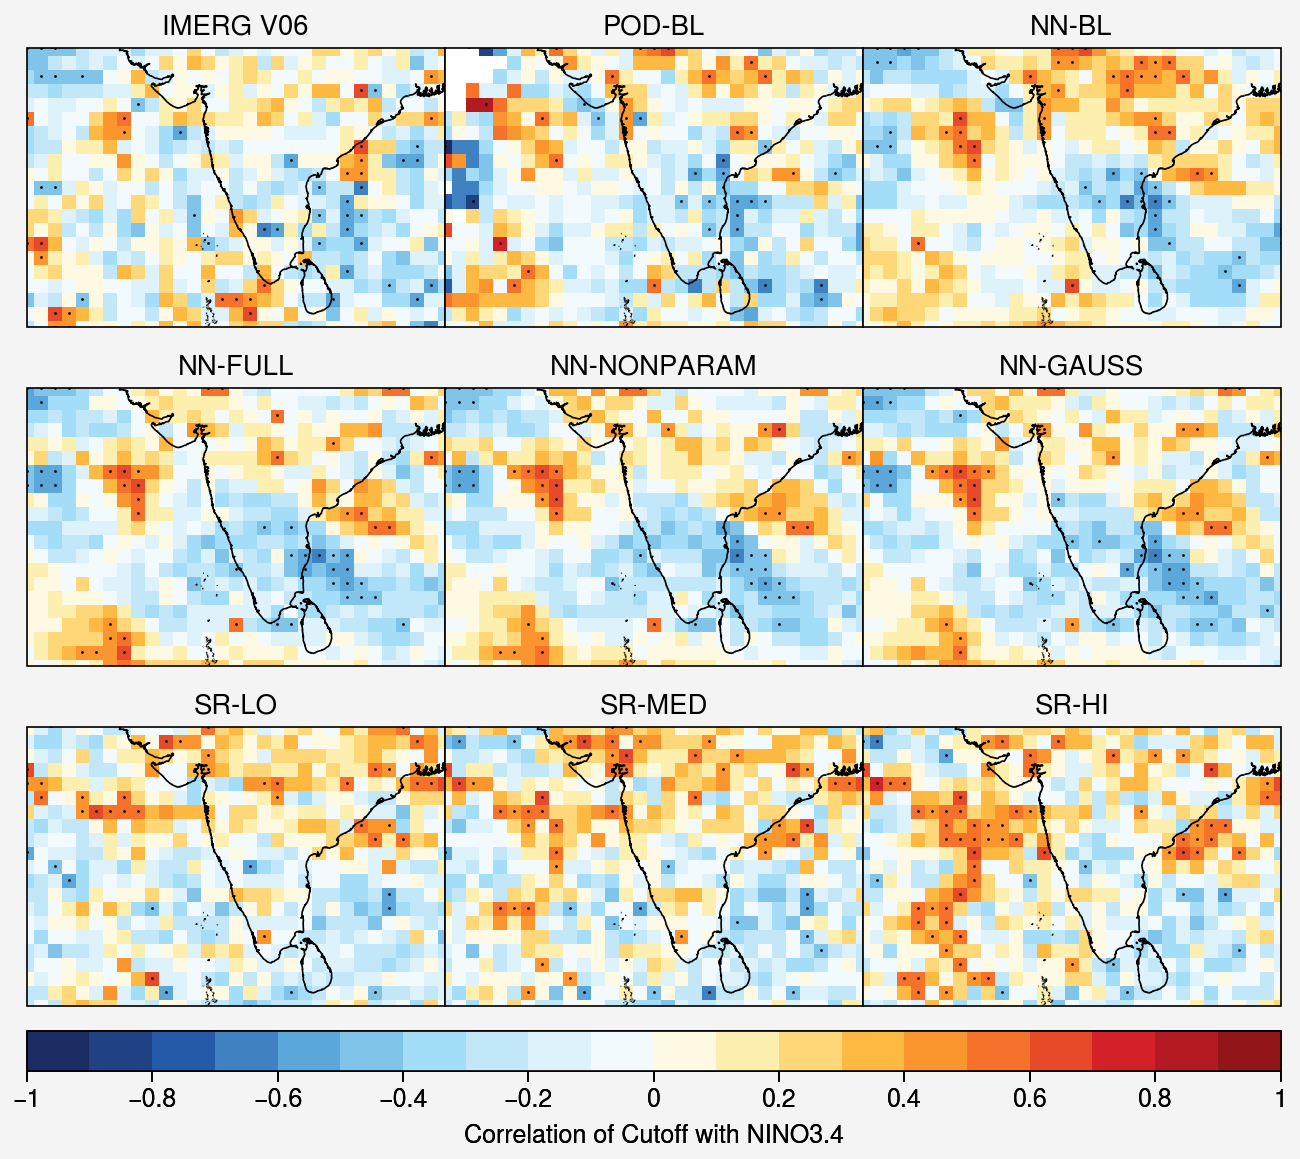

In [18]:
PANEL_ORDER = ['imerg','pod_bl','nn_bl','nn_full','nn_nonparam','nn_gauss','sr_lo','sr_med','sr_hi']
PANEL_LABELS = {
    'imerg':      'IMERG V06',
    'pod_bl':     MODELS['pod']['runs']['pod_bl']['description'],
    'nn_bl':      MODELS['nn']['runs']['nn_bl']['description'],
    'nn_full':    MODELS['nn']['runs']['nn_full']['description'],
    'nn_nonparam':MODELS['nn']['runs']['nn_nonparam']['description'],
    'nn_gauss':   MODELS['nn']['runs']['nn_gauss']['description'],
    'sr_lo':      MODELS['sr']['optimizedeqs']['sr_lo']['description'],
    'sr_med':     MODELS['sr']['optimizedeqs']['sr_med']['description'],
    'sr_hi':      MODELS['sr']['optimizedeqs']['sr_hi']['description'],
}

fig,axs = pplt.subplots(nrows=3,ncols=3,proj='cyl',figwidth=6.5,wspace=0)
axs.format(grid=False,coast=True,latlim=(LATRANGE[0],LATRANGE[1]),lonlim=(LONRANGE[0],LONRANGE[1]),
           latlines=5,lonlines=5)
mappable = None
for ax,name in zip(axs,PANEL_ORDER):
    ax.format(title=PANEL_LABELS[name])
    if name not in all_preds:
        continue
    r,p = all_preds[name]
    m = ax.pcolormesh(r.lon.values,r.lat.values,r.values,cmap='ColdHot',vmin=-1,vmax=1,levels=20)
    if mappable is None:
        mappable = m
    if p is not None:
        pmask = p.values < 0.05
        if pmask.any():
            lons2d,lats2d = np.meshgrid(r.lon.values,r.lat.values)
            ax.scatter(lons2d[pmask],lats2d[pmask],c='k',s=1,zorder=5,linewidths=0)
fig.colorbar(mappable,loc='b',label='Correlation of Cutoff with NINO3.4')
fig.save('../figs/fig_4_cutoff.jpg')
pplt.show()

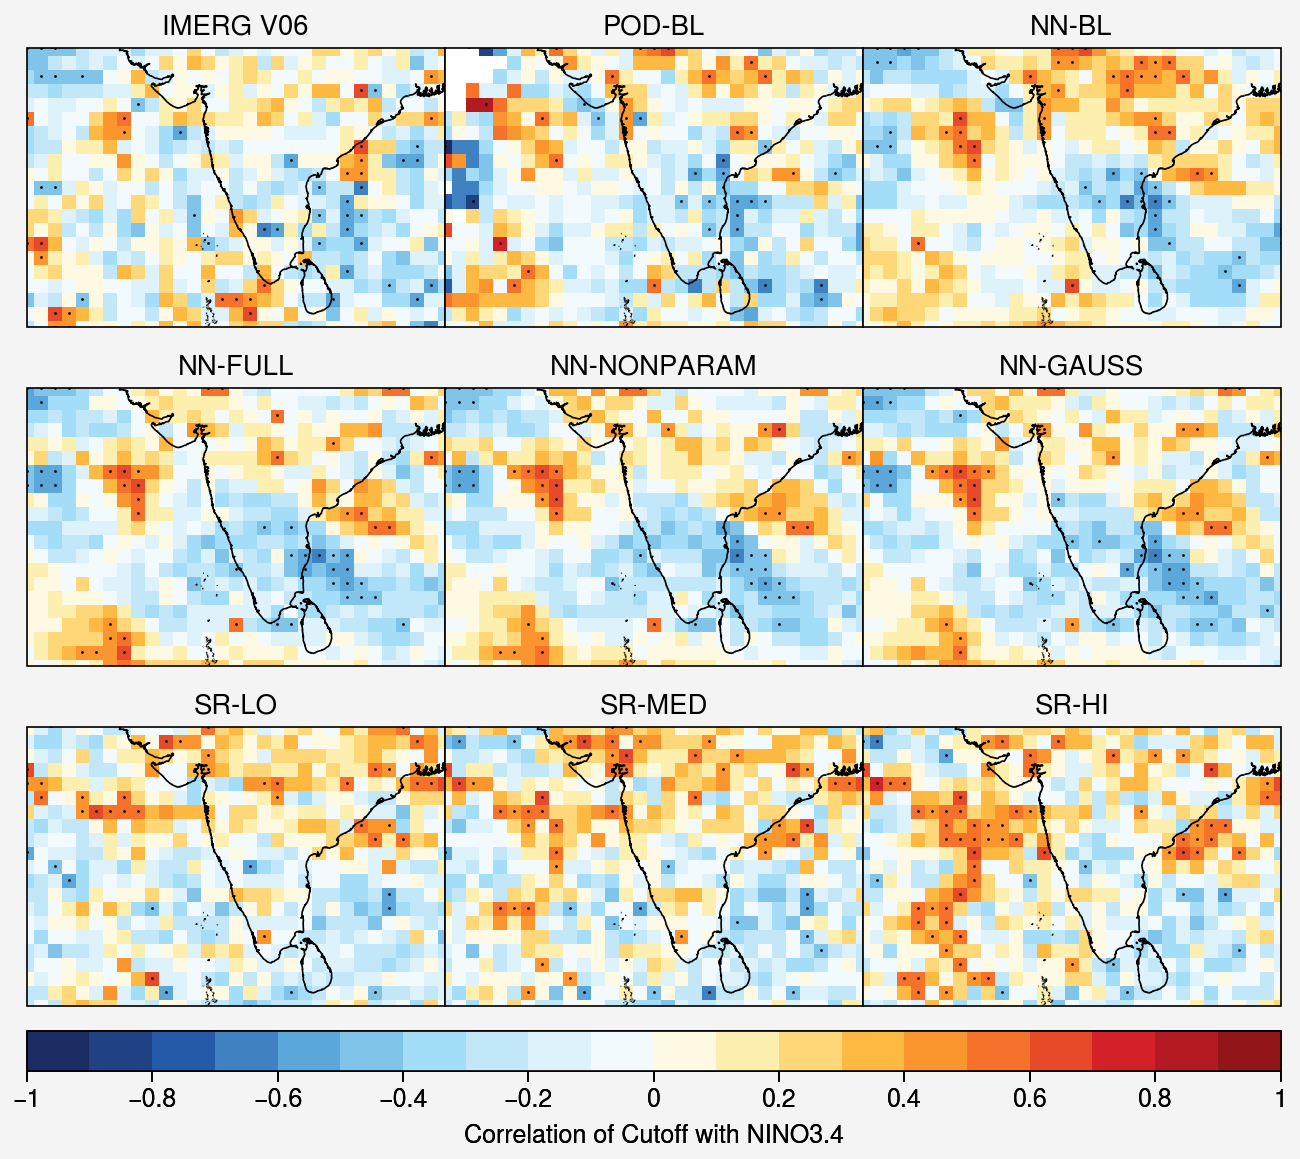

In [8]:
PANEL_ORDER = ['imerg','pod_bl','nn_bl','nn_full','nn_nonparam','nn_gauss','sr_lo','sr_med','sr_hi']
PANEL_LABELS = {
    'imerg':      'IMERG V06',
    'pod_bl':     MODELS['pod']['runs']['pod_bl']['description'],
    'nn_bl':      MODELS['nn']['runs']['nn_bl']['description'],
    'nn_full':    MODELS['nn']['runs']['nn_full']['description'],
    'nn_nonparam':MODELS['nn']['runs']['nn_nonparam']['description'],
    'nn_gauss':   MODELS['nn']['runs']['nn_gauss']['description'],
    'sr_lo':      MODELS['sr']['optimizedeqs']['sr_lo']['description'],
    'sr_med':     MODELS['sr']['optimizedeqs']['sr_med']['description'],
    'sr_hi':      MODELS['sr']['optimizedeqs']['sr_hi']['description'],
}

fig,axs = pplt.subplots(nrows=3,ncols=3,proj='cyl',figwidth=6.5,wspace=0)
axs.format(grid=False,coast=True,latlim=(LATRANGE[0],LATRANGE[1]),lonlim=(LONRANGE[0],LONRANGE[1]),
           latlines=5,lonlines=5)
mappable = None
for ax,name in zip(axs,PANEL_ORDER):
    ax.format(title=PANEL_LABELS[name])
    if name not in all_preds:
        continue
    r,p = all_preds[name]
    m = ax.pcolormesh(r.lon.values,r.lat.values,r.values,cmap='ColdHot',vmin=-1,vmax=1,levels=20)
    if mappable is None:
        mappable = m
    if p is not None:
        pmask = p.values < 0.05
        if pmask.any():
            lons2d,lats2d = np.meshgrid(r.lon.values,r.lat.values)
            ax.scatter(lons2d[pmask],lats2d[pmask],c='k',s=1,zorder=5,linewidths=0)
fig.colorbar(mappable,loc='b',label='Correlation of Cutoff with NINO3.4')
fig.save('../figs/fig_4_cutoff.jpg')
pplt.show()